# ML Random Tree and Random Forest models for the TPG data

We will use scikit-learn library to create some machine learning models for the TPG data. We will start with a Random Tree model and then move on to a Random Forest model.

In [1]:
import numpy as np
import datetime as dt
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# A function to display more columns and rows in the output of a dataframe
def display_df(df, max_rows=-1, max_cols=-1):
    with pl.Config(tbl_cols=max_cols, tbl_width_chars=-1, tbl_rows=max_rows):
        print(df)

## Data Description

Load the TPG and MeteoSwiss dataset. The ridership data has been aggregated by line.

In [2]:
initial_dataset_df = pl.read_parquet("./data/line_aggregated_tpg_and_meteo.parquet")
display(initial_dataset_df.sample(n=5, seed=42))

Line,Date,total_number_of_boarding_passengers,total_number_of_disembarking_passengers,line_type,day_week,schedule_type,precipitation_in_mm,mean_air_temperature_2m_in_C,minimum_air_temperature_2m_in_C,maximum_air_temperature_2m_in_C,is_autumn_vacation,is_winter_vacation,is_february_vacation,is_easter_vacation,is_summer_vacation,is_public_holiday,is_servette_hc_home_match
str,date,f64,f64,str,str,str,f64,f64,f64,f64,bool,bool,bool,bool,bool,bool,bool
"""G+""",2025-09-23,386.99,387.05,"""SECONDAIRE""","""2-Mardi""","""NORMAL""",4.9,11.7,9.7,14.5,false,false,false,false,false,false,true
"""56""",2024-02-01,403.53,403.58,"""SECONDAIRE""","""4-Jeudi""","""NORMAL""",0.1,3.9,-1.8,7.5,false,false,false,false,false,false,false
"""60""",2026-04-10,8343.24,8401.21,"""GLCT""","""5-Vendredi""","""VACANCES""",0.0,15.3,7.5,23.3,false,false,false,true,false,false,true
"""32""",2025-05-09,3501.03,3501.42,"""SECONDAIRE""","""5-Vendredi""","""NORMAL""",0.0,12.6,8.3,17.6,false,false,false,false,false,false,false
"""14""",2025-08-31,47745.66,47744.44,"""PRINCIPAL""","""7-Dimanche""","""DIMANCHE""",17.7,18.4,11.1,25.3,false,false,false,false,false,false,false


In [3]:
# Show the columns of the dataset
display(initial_dataset_df.columns)

# Show the shape of the dataset
display(initial_dataset_df.shape)

# Show some statistics of the dataset
display(initial_dataset_df.describe())

['Line',
 'Date',
 'total_number_of_boarding_passengers',
 'total_number_of_disembarking_passengers',
 'line_type',
 'day_week',
 'schedule_type',
 'precipitation_in_mm',
 'mean_air_temperature_2m_in_C',
 'minimum_air_temperature_2m_in_C',
 'maximum_air_temperature_2m_in_C',
 'is_autumn_vacation',
 'is_winter_vacation',
 'is_february_vacation',
 'is_easter_vacation',
 'is_summer_vacation',
 'is_public_holiday',
 'is_servette_hc_home_match']

(89287, 18)

statistic,Line,Date,total_number_of_boarding_passengers,total_number_of_disembarking_passengers,line_type,day_week,schedule_type,precipitation_in_mm,mean_air_temperature_2m_in_C,minimum_air_temperature_2m_in_C,maximum_air_temperature_2m_in_C,is_autumn_vacation,is_winter_vacation,is_february_vacation,is_easter_vacation,is_summer_vacation,is_public_holiday,is_servette_hc_home_match
str,str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""89287""","""89287""",89287.0,89287.0,"""89287""","""89287""","""89287""",89287.0,89287.0,89287.0,89287.0,89287.0,89287.0,89287.0,89287.0,89287.0,89287.0,89287.0
"""null_count""","""0""","""0""",0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,"""2024-09-09 19:45:43.776809""",8135.847951,8136.609402,null,null,null,2.633036,11.87949,6.988539,16.861655,0.021268,0.036231,0.0266,0.053513,0.121686,0.024752,0.0842
"""std""",null,null,15294.847895,15295.664773,null,null,null,6.210061,7.154726,6.355334,8.501921,null,null,null,null,null,null,null
"""min""","""1""","""2023-02-01""",0.0,0.0,"""GLCT""","""1-Lundi""","""DIMANCHE""",0.0,-4.7,-9.9,-0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,"""2023-11-12""",437.54,437.58,null,null,null,0.0,6.1,1.8,10.4,null,null,null,null,null,null,null
"""50%""",null,"""2024-09-10""",2030.2,2031.22,null,null,null,0.0,11.3,6.8,16.0,null,null,null,null,null,null,null
"""75%""",null,"""2025-07-07""",8845.93,8840.64,null,null,null,1.7,17.7,11.9,23.4,null,null,null,null,null,null,null
"""max""","""T""","""2026-04-29""",122940.11,123125.4,"""SECONDAIRE""","""7-Dimanche""","""VACANCES""",47.6,29.3,20.8,39.3,1.0,1.0,1.0,1.0,1.0,1.0,1.0


The dataset contains the following columns:
- `Date`: the date of the observation
- `Line`: the line of the TPG network
- `total_number_of_boarding_passengers`: the number of boarding passengers on that line and date
- `total_number_of_disembarking_passengers`: the number of disembarking passengers on that line and date
- `line_type`: the type of line (principal, secondaire etc.)
- `day_week`: the day of the week
- `schedule_type`: the type of schedule (weekday, saturday, sunday, holiday)
- `precipitation_in_mm`: the amount of precipitation in mm on that date
- `mean_air_temperature_2m_in_C`: float, the mean air temperature at 2m in °C on that date
- `minimum_air_temperature_2m_in_C`: float, the minimum air temperature at 2m in °C on that date
- `maximum_air_temperature_2m_in_C`: float, the maximum air temperature at 2m in °C on that date
- `is_autumn_vacation`: boolean, if the date is in the autumn vacation period
- `is_winter_vacation`: boolean, if the date is in the winter vacation period
- `is_february_vacation`: boolean, if the date is in the february vacation period
- `is_easter_vacation`: boolean, if the date is in the easter vacation period
- `is_summer_vacation`: boolean, if the date is in the summer vacation period
- `is_public_holiday`: boolean, if the date is a public holiday
- `is_servette_hc_home_match`: boolean, if there is a Servette HC home match on that date

We will remove the `Date`, the `total_number_of_disembarking_passengers` the `minimum_air_temperature_2m_in_C` and `maximum_air_temperature_2m_in_C` columns from our analysis.

With the ML model, we want to predict the `total_number_of_boarding_passengers` column, using the other columns as features.
The vacation and public holiday columns should have a strong influence on the number of passengers. We also want to find out if the weather has an influence on the number of passengers, and if there are some differences between the different lines and line types. For the fun of, we also want to check if the Servette HC home matches have an influence on the number of passengers for some lines.

In [4]:
# Save some of the date info in case
min_date_dataset = initial_dataset_df["Date"].min()
max_date_dataset = initial_dataset_df["Date"].max()
print(f"Dataset date range: {min_date_dataset} - {max_date_dataset}")
print(f"Dataset date range in days: {(max_date_dataset - min_date_dataset).days} days")

# Remove the columns that we won't use for the analysis
columns_to_drop = ["Date", "total_number_of_disembarking_passengers",
                   "minimum_air_temperature_2m_in_C", "maximum_air_temperature_2m_in_C"]

dataset_df = initial_dataset_df.drop(columns_to_drop)
dataset_df.sample(n=5, seed=42)

Dataset date range: 2023-02-01 - 2026-04-29
Dataset date range in days: 1183 days


Line,total_number_of_boarding_passengers,line_type,day_week,schedule_type,precipitation_in_mm,mean_air_temperature_2m_in_C,is_autumn_vacation,is_winter_vacation,is_february_vacation,is_easter_vacation,is_summer_vacation,is_public_holiday,is_servette_hc_home_match
str,f64,str,str,str,f64,f64,bool,bool,bool,bool,bool,bool,bool
"""G+""",386.99,"""SECONDAIRE""","""2-Mardi""","""NORMAL""",4.9,11.7,false,false,false,false,false,false,true
"""56""",403.53,"""SECONDAIRE""","""4-Jeudi""","""NORMAL""",0.1,3.9,false,false,false,false,false,false,false
"""60""",8343.24,"""GLCT""","""5-Vendredi""","""VACANCES""",0.0,15.3,false,false,false,true,false,false,true
"""32""",3501.03,"""SECONDAIRE""","""5-Vendredi""","""NORMAL""",0.0,12.6,false,false,false,false,false,false,false
"""14""",47745.66,"""PRINCIPAL""","""7-Dimanche""","""DIMANCHE""",17.7,18.4,false,false,false,false,false,false,false


In [5]:
display_df(dataset_df["Line"].unique().sort())
display_df(dataset_df["line_type"].unique().sort())
display_df(dataset_df["day_week"].unique().sort())
display_df(dataset_df["schedule_type"].unique().sort())

shape: (112,)
Series: 'Line' [str]
[
	"1"
	"10"
	"11"
	"12"
	"14"
	"15"
	"17"
	"18"
	"19"
	"2"
	"20"
	"21"
	"22"
	"23"
	"25"
	"28"
	"29"
	"3"
	"301"
	"302"
	"303"
	"31"
	"32"
	"33"
	"34"
	"35"
	"36"
	"37"
	"38"
	"39"
	"40"
	"41"
	"42"
	"43"
	"44"
	"45"
	"46"
	"47"
	"48"
	"5"
	"50"
	"51"
	"52"
	"53"
	"54"
	"55"
	"56"
	"57"
	"58"
	"59"
	"6"
	"60"
	"61"
	"62"
	"63"
	"64"
	"66"
	"67"
	"68"
	"69"
	"7"
	"70"
	"71"
	"72"
	"73"
	"74"
	"75"
	"76"
	"77"
	"78"
	"8"
	"80"
	"82"
	"83"
	"86"
	"9"
	"91"
	"92"
	"97"
	"A"
	"C1"
	"C3"
	"C4"
	"C5"
	"C6"
	"C7"
	"C8"
	"C9"
	"D"
	"E"
	"E+"
	"F"
	"G"
	"G+"
	"J"
	"K"
	"L"
	"M"
	"N"
	"NA"
	"NC"
	"ND"
	"NE"
	"NJ"
	"NK"
	"NM"
	"NO"
	"NP"
	"NS"
	"NT"
	"NV"
	"T"
]
shape: (5,)
Series: 'line_type' [str]
[
	"GLCT"
	"NOCTAMBUS REGIONAL"
	"PRINCIPAL"
	"SCOLAIRE"
	"SECONDAIRE"
]
shape: (7,)
Series: 'day_week' [str]
[
	"1-Lundi"
	"2-Mardi"
	"3-Mercredi"
	"4-Jeudi"
	"5-Vendredi"
	"6-Samedi"
	"7-Dimanche"
]
shape: (4,)
Series: 'schedule_type' [str]
[
	"DIMANCHE"
	"NORMAL"


In [6]:
# We further remove the "SCOLAIRE" `schdule_type`, to concentrate on PRINCIPALE, SECONDAIRE and
# GLCT (Groupement Local de Coopération Transfrontalière), transfrontalière lines, which are the most relevant for our analysis.

dataset_df = dataset_df.filter(pl.col("schedule_type") != "SCOLAIRE")
dataset_df.sample(n=5, seed=42)

Line,total_number_of_boarding_passengers,line_type,day_week,schedule_type,precipitation_in_mm,mean_air_temperature_2m_in_C,is_autumn_vacation,is_winter_vacation,is_february_vacation,is_easter_vacation,is_summer_vacation,is_public_holiday,is_servette_hc_home_match
str,f64,str,str,str,f64,f64,bool,bool,bool,bool,bool,bool,bool
"""G+""",386.99,"""SECONDAIRE""","""2-Mardi""","""NORMAL""",4.9,11.7,false,false,false,false,false,false,true
"""56""",403.53,"""SECONDAIRE""","""4-Jeudi""","""NORMAL""",0.1,3.9,false,false,false,false,false,false,false
"""60""",8343.24,"""GLCT""","""5-Vendredi""","""VACANCES""",0.0,15.3,false,false,false,true,false,false,true
"""32""",3501.03,"""SECONDAIRE""","""5-Vendredi""","""NORMAL""",0.0,12.6,false,false,false,false,false,false,false
"""14""",47745.66,"""PRINCIPAL""","""7-Dimanche""","""DIMANCHE""",17.7,18.4,false,false,false,false,false,false,false


In [7]:
# Transform the day_week data to integers, where 0 is Monday and 6 is Sunday
dataset_df = dataset_df.with_columns(pl.col("day_week").str.head(1).cast(pl.Int8))
dataset_df.sample(n=5, seed=42)

# Transform the line, line_type schedule_type to categorical data
dataset_df = dataset_df.with_columns(pl.col("Line").cast(pl.Categorical))
dataset_df = dataset_df.with_columns(pl.col("line_type").cast(pl.Categorical))
dataset_df = dataset_df.with_columns(pl.col("schedule_type").cast(pl.Categorical))
dataset_df.sample(n=5, seed=42)

Line,total_number_of_boarding_passengers,line_type,day_week,schedule_type,precipitation_in_mm,mean_air_temperature_2m_in_C,is_autumn_vacation,is_winter_vacation,is_february_vacation,is_easter_vacation,is_summer_vacation,is_public_holiday,is_servette_hc_home_match
cat,f64,cat,i8,cat,f64,f64,bool,bool,bool,bool,bool,bool,bool
"""G+""",386.99,"""SECONDAIRE""",2,"""NORMAL""",4.9,11.7,false,false,false,false,false,false,true
"""56""",403.53,"""SECONDAIRE""",4,"""NORMAL""",0.1,3.9,false,false,false,false,false,false,false
"""60""",8343.24,"""GLCT""",5,"""VACANCES""",0.0,15.3,false,false,false,true,false,false,true
"""32""",3501.03,"""SECONDAIRE""",5,"""NORMAL""",0.0,12.6,false,false,false,false,false,false,false
"""14""",47745.66,"""PRINCIPAL""",7,"""DIMANCHE""",17.7,18.4,false,false,false,false,false,false,false


In [8]:
# Show violin plots of the number of boarding passengers for the tram lines over the full dataset
tram_lines = ["12", "14", "15", "17", "18"]

dataset_df_tram = dataset_df.filter(pl.col("Line").is_in(tram_lines))
dataset_df_tram.head()

Line,total_number_of_boarding_passengers,line_type,day_week,schedule_type,precipitation_in_mm,mean_air_temperature_2m_in_C,is_autumn_vacation,is_winter_vacation,is_february_vacation,is_easter_vacation,is_summer_vacation,is_public_holiday,is_servette_hc_home_match
cat,f64,cat,i8,cat,f64,f64,bool,bool,bool,bool,bool,bool,bool
"""12""",72106.72,"""PRINCIPAL""",3,"""NORMAL""",0.0,2.8,false,false,false,false,false,false,false
"""14""",89565.08,"""PRINCIPAL""",3,"""NORMAL""",0.0,2.8,false,false,false,false,false,false,false
"""15""",61759.27,"""PRINCIPAL""",3,"""NORMAL""",0.0,2.8,false,false,false,false,false,false,false
"""17""",34620.43,"""PRINCIPAL""",3,"""NORMAL""",0.0,2.8,false,false,false,false,false,false,false
"""18""",55472.95,"""PRINCIPAL""",3,"""NORMAL""",0.0,2.8,false,false,false,false,false,false,false


Text(0.5, 0.98, 'Distribution of the number of boarding passengers for the tram lines per day\nPeriod from 2023-02-01 to 2026-04-29')

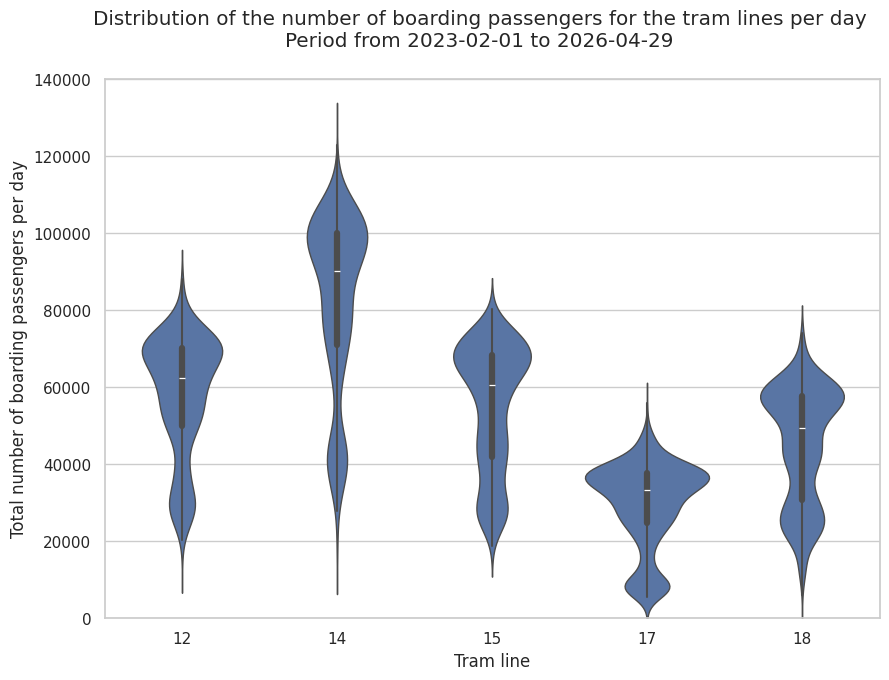

In [9]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 7))

sns.violinplot(x="Line",
               y="total_number_of_boarding_passengers", data=dataset_df_tram.to_pandas(),
               ax=ax, linewidth=1)

ax.set_ylabel("Total number of boarding passengers per day")
ax.set_xlabel("Tram line")

ax.set_ylim(0, 140000)

fig.suptitle(f"Distribution of the number of boarding passengers for the tram lines per day\nPeriod from {min_date_dataset} to {max_date_dataset}")

In [10]:
# Create a new feature is_holiday that combines all the is_*_vacation and is_public_holiday features
dataset_df = dataset_df.with_columns(
    pl.any_horizontal(pl.col("^is_.*_vacation$"), pl.col("is_public_holiday")).alias("is_any_holiday")
)

Create violin plots showing the daily passenger traffic per day of the week for all lines, making the distinction between is_any_holiday and non-holiday days.

In [11]:
# Aggregate the data by day of the week and is_any_holiday, and calculate the total number of boarding passengers for each group
# dataset_df_agg = dataset_df
# Keep only the PRINCIPAL and GLCT lines to reduce the dataset size

names_of_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df_to_plot = (dataset_df
               .filter(pl.col("line_type").is_in(["PRINCIPAL", "GLCT"]))
               .group_by(["day_week", "is_any_holiday"])
               .agg(pl.col("total_number_of_boarding_passengers"))
               .explode("total_number_of_boarding_passengers")).to_pandas()

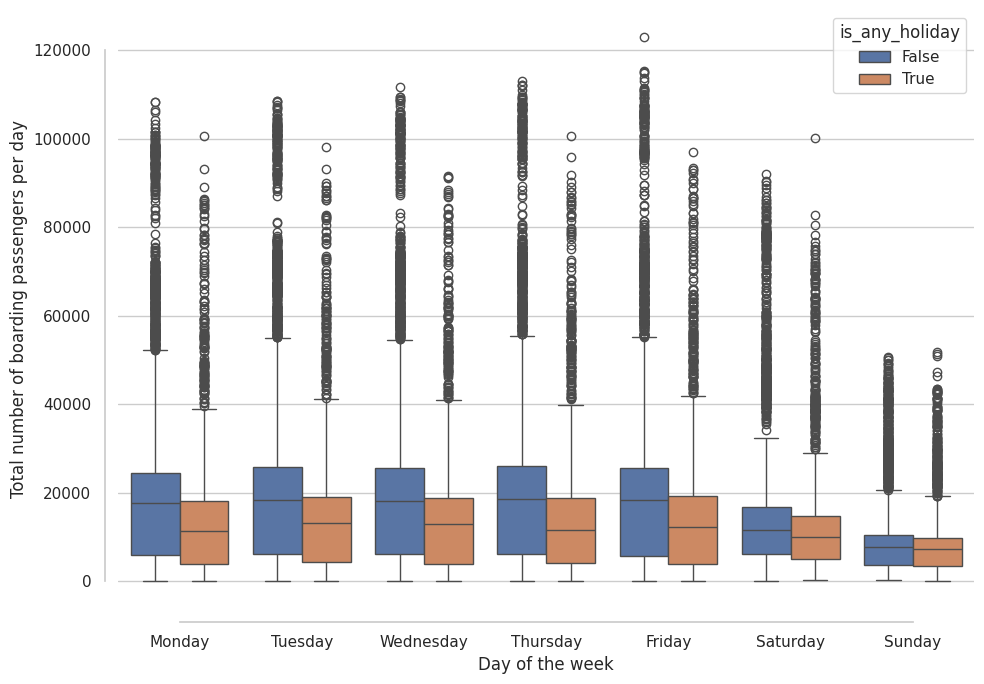

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(data=df_to_plot,
               x="day_week",
               y="total_number_of_boarding_passengers",
               hue="is_any_holiday",
               ax=ax, linewidth=1)
sns.despine(offset=10, trim=True)

ax.set_xticklabels(names_of_days)
ax.set_xlabel("Day of the week")
ax.set_ylabel("Total number of boarding passengers per day")

fig.tight_layout()

## Building the ML models

We will now build different machine learning models to predict the number of boarding passengers on the TPG network, given the holidays periods and the weather conditions. We will use tree based models, as they are easy to interpret and can handle both numerical and categorical features. We will start with a simple Decision Tree, then we will try a Random Forest and a Gradient Boosting model. We will also use SHAP values to interpret the models and understand which features are the most important for the predictions.

In [13]:
# Convert the dataset to a pandas dataframe for the machine learning part, and separate the target variable from the features
dataset_pdf = dataset_df.to_pandas()
dataset_pdf.sample(n=5)

# Create the list of features and the target variable
target_variable = "total_number_of_boarding_passengers"
fields = dataset_pdf.columns.to_list()
fields.remove("total_number_of_boarding_passengers")


In [14]:
from sklearn.model_selection import ShuffleSplit

# Split the data into two parts
strat_shuff_split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get the index values from the generator
train_idx, test_idx = next(strat_shuff_split.split(dataset_pdf[fields], dataset_pdf['total_number_of_boarding_passengers']))

# Create the data sets
X_train = dataset_pdf.loc[train_idx, fields]
y_train = dataset_pdf.loc[train_idx, 'total_number_of_boarding_passengers']

X_test = dataset_pdf.loc[test_idx, fields]
y_test = dataset_pdf.loc[test_idx, 'total_number_of_boarding_passengers']

In [15]:
label_columns = ["Line", "line_type", "schedule_type"]
other_columns = [col for col in fields if col not in label_columns]

### Decision Tree

In [16]:
# Create a pipeline that will encode the "Line", "line_type" and "schedule_type" categorical features to numerical values using LabelEncoder
# We will then add Random Tree and Random Forest Regressor afterwards
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

one_hot_encoder = OneHotEncoder()

preprocessing = ColumnTransformer(
    [
        ("cat", one_hot_encoder, label_columns),
        ("num_and_bool", "passthrough", other_columns)
    ],
    verbose_feature_names_out=True,
)

In [17]:
decision_tree = DecisionTreeRegressor(random_state=42)

In [18]:
# Create a first pipeline that will preprocess the data and then fit a decision tree regressor
decision_tree_pipeline = Pipeline(
    [
        ("preprocess", preprocessing),
        ("regressor", decision_tree)
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num_and_bool', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [19]:
# Show the hyperparameters of the decision tree
print("Decision tree hyperparameters:")
print(f"Node count: {decision_tree_pipeline['regressor'].tree_.node_count}")
print(f"Max depth: {decision_tree_pipeline['regressor'].tree_.max_depth}")
print(f"Max features: {len(decision_tree_pipeline['regressor'].feature_importances_)}")

# Store the max depth and feature importances for later use in the grid search
max_depth = decision_tree_pipeline['regressor'].tree_.max_depth
feature_importances = decision_tree_pipeline['regressor'].feature_importances_

Decision tree hyperparameters:
Node count: 137751
Max depth: 93
Max features: 132


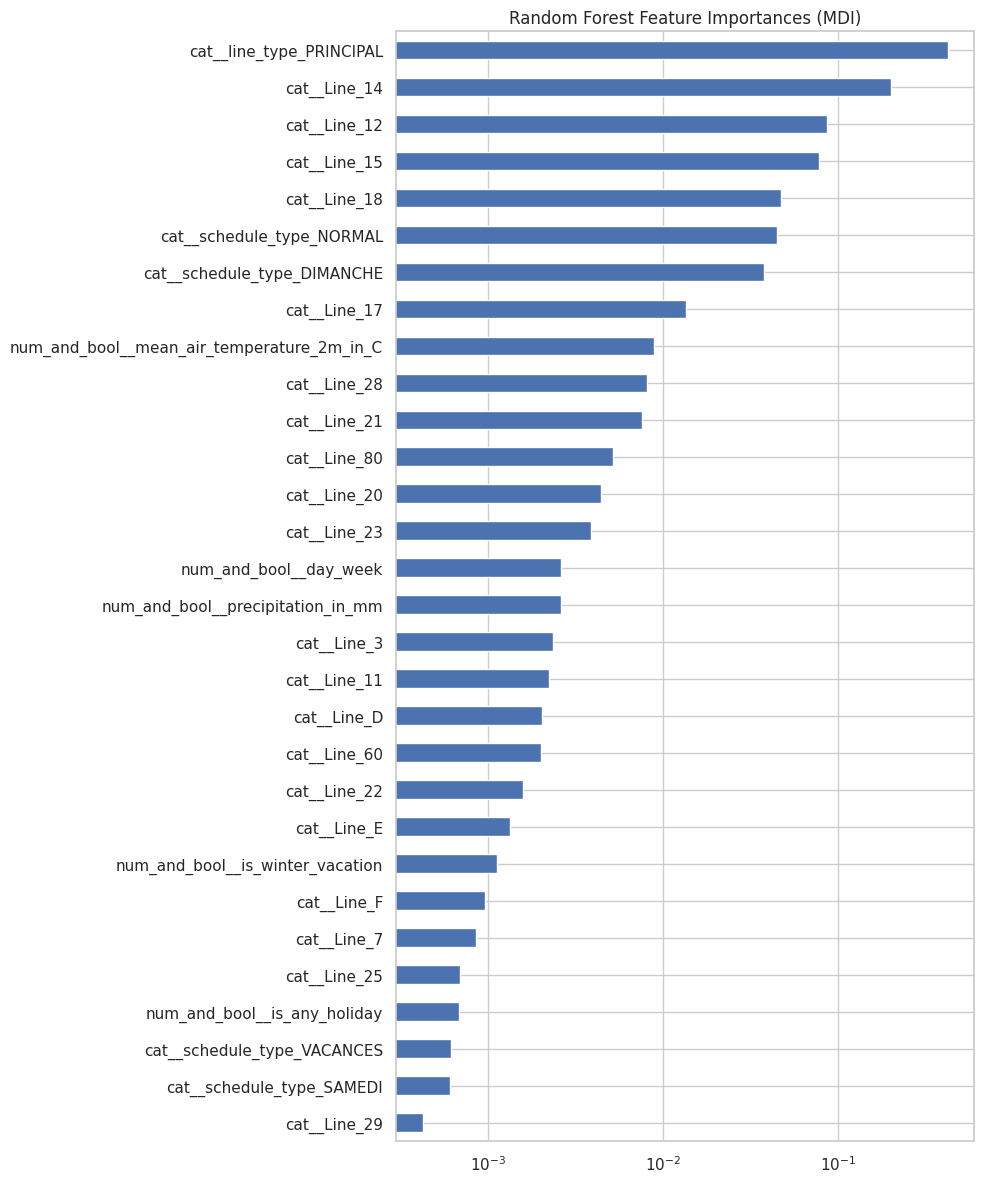

In [20]:
feature_names = decision_tree_pipeline[:-1].get_feature_names_out()

mdi_importances = pd.Series(
    decision_tree_pipeline[-1].feature_importances_, index=feature_names
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))

mdi_importances[-30:].plot.barh(ax=ax)
ax.set_xscale("log")
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

In [21]:
from sklearn.metrics import mean_squared_error, r2_score

# A short function to show some regression metrics
def regression_metrics(y_true, y_pred, label=""):
    """Compute and give the regression model metrics

    Parameters
    ----------
    y_true : array-like        The true values of the target variable.
    y_pred : array-like        The predicted values of the target variable.
    label : str, optional     A label to identify the metrics, by default "".
    """

    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return pd.Series({'mse': mse, 'r2': r2}, name=label)

In [22]:
y_train_pred_gr = decision_tree_pipeline.predict(X_train)
y_test_pred_gr = decision_tree_pipeline.predict(X_test)

train_test_gr_error = pd.concat([regression_metrics(y_train, y_train_pred_gr, 'train'),
                                 regression_metrics(y_test, y_test_pred_gr, 'test')],
                                axis=1)
print("Train and test regression metrics for the base decision tree without hyper:")
display(train_test_gr_error)

Train and test regression metrics for the base decision tree without hyper:


,train,test
mse,129842.387601,6.321303e+06
r2,0.999443,9.732986e-01


We will do a Grid Search cross validation to find the best hyperparameters.

In [30]:
from sklearn.model_selection import GridSearchCV

# The grid search will test different values of max_depth and max_features,
# which are  important hyperparameters for a decision tree regressor.
# We will use the max depth of the initial decision tree as the maximum value for the grid search,
# and we will use the number of features as the maximum value for max_features.
range_max_depth = range(1, max_depth, 10)
print(f"Max depth range for grid search: {list(range_max_depth)}")
range_max_features = range(1, len(feature_importances)+1, 10)
print(f"Max features range for grid search: {list(range_max_features)}")

param_grid = [{'regressor__max_depth': range_max_depth,
               'regressor__max_features': range_max_features}
              ]

Max depth range for grid search: [1, 11, 21, 31, 41, 51, 61, 71, 81, 91]
Max features range for grid search: [1, 11, 21, 31, 41, 51, 61, 71, 81, 91, 101, 111, 121, 131]


In [31]:
decision_tree_gridsearch = GridSearchCV(decision_tree_pipeline,
                  param_grid=param_grid,
                  scoring='neg_mean_squared_error',
                  n_jobs=-1, verbose=10)

decision_tree_gridsearch = decision_tree_gridsearch.fit(X_train, y_train)

Fitting 5 folds for each of 140 candidates, totalling 700 fits
[CV 1/5; 1/140] START regressor__max_depth=1, regressor__max_features=1.........
[CV 1/5; 1/140] END regressor__max_depth=1, regressor__max_features=1;, score=-233152446.152 total time=   0.3s
[CV 5/5; 1/140] START regressor__max_depth=1, regressor__max_features=1.........
[CV 4/5; 1/140] START regressor__max_depth=1, regressor__max_features=1.........
[CV 3/5; 1/140] START regressor__max_depth=1, regressor__max_features=1.........
[CV 5/5; 1/140] END regressor__max_depth=1, regressor__max_features=1;, score=-225095485.212 total time=   0.7s
[CV 1/5; 2/140] START regressor__max_depth=1, regressor__max_features=11........
[CV 2/5; 1/140] START regressor__max_depth=1, regressor__max_features=1.........
[CV 1/5; 2/140] END regressor__max_depth=1, regressor__max_features=11;, score=-233334226.595 total time=   0.4s
[CV 2/5; 2/140] START regressor__max_depth=1, regressor__max_features=11........
[CV 4/5; 1/140] END regressor__ma

In [41]:
print(decision_tree_gridsearch.best_estimator_["regressor"].tree_.node_count)
print(decision_tree_gridsearch.best_estimator_["regressor"].tree_.max_depth)
print(decision_tree_gridsearch.best_estimator_["regressor"].get_params())

max_depth_cv = decision_tree_gridsearch.best_estimator_["regressor"].tree_.max_depth
max_features_cv = len(decision_tree_gridsearch.best_estimator_["regressor"].feature_importances_)

27983
21
{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 21, 'max_features': 71, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [34]:
y_train_pred_gr = decision_tree_gridsearch.predict(X_train)
y_test_pred_gr = decision_tree_gridsearch.predict(X_test)

train_test_gr_error = pd.concat([regression_metrics(y_train, y_train_pred_gr, 'train'),
                                 regression_metrics(y_test, y_test_pred_gr, 'test')],
                                axis=1)
print("Train and test regression metrics for the best decision tree found by Grid Search:")
display(train_test_gr_error)

Train and test regression metrics for the best decision tree found by Grid Search:


,train,test
mse,1.285989e+06,5.182553e+06
r2,9.944861e-01,9.781087e-01


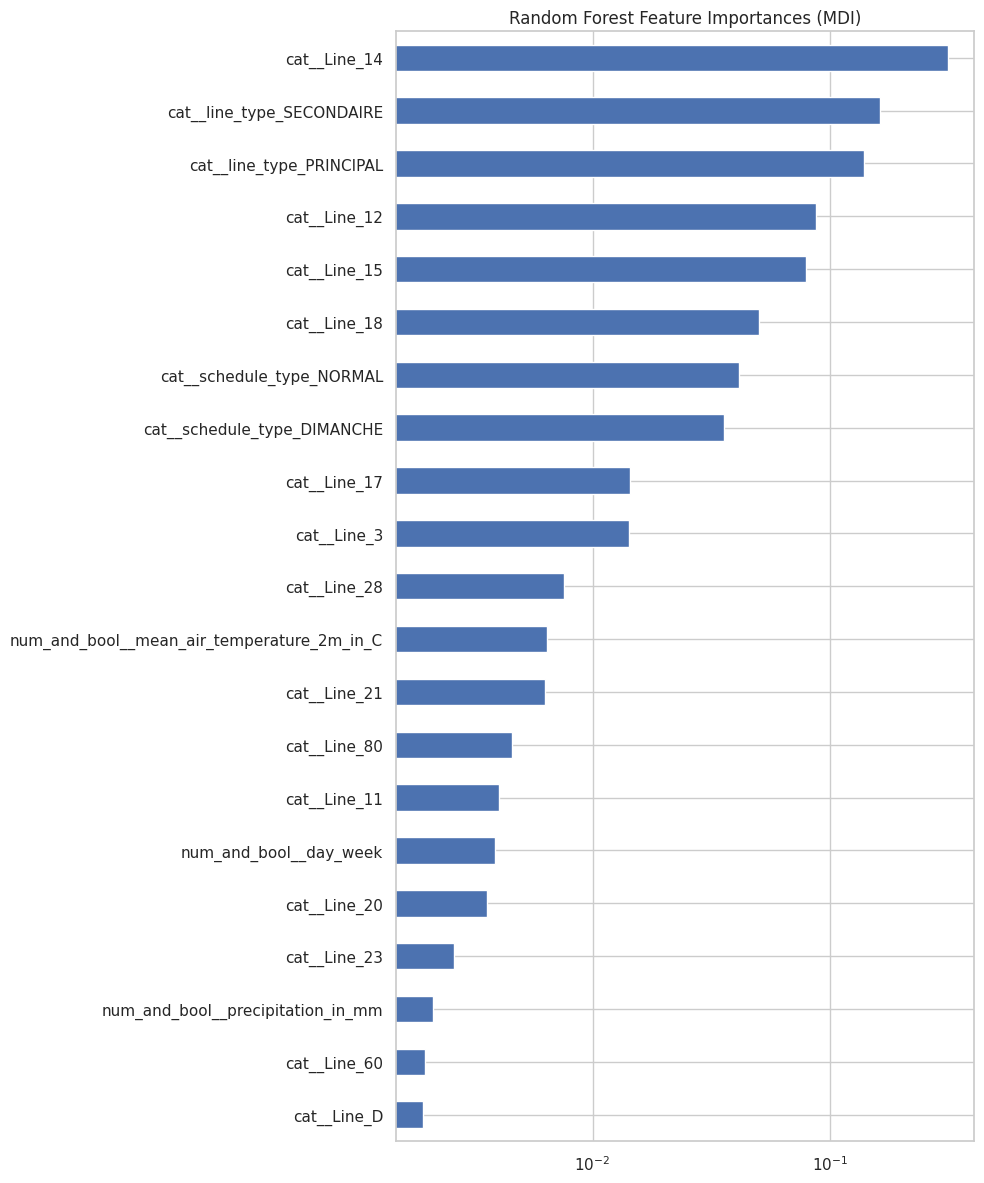

In [42]:
feature_names = decision_tree_gridsearch.best_estimator_[:-1].get_feature_names_out()

mdi_importances = pd.Series(
    decision_tree_gridsearch.best_estimator_[-1].feature_importances_, index=feature_names
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))

mdi_importances[-21:].plot.barh(ax=ax)
ax.set_xscale("log")
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

### Random Forest
We will now use Random Forest to try improve the prediction.

In [44]:
from sklearn.ensemble import RandomForestRegressor
import timeit

# Initialize the random forest estimator
# Note that the number of trees is not setup here
random_forest = RandomForestRegressor(oob_score=True, 
                            random_state=42, 
                            warm_start=False,
                            max_depth=max_depth_cv,
                            max_features=max_features_cv,
                            n_jobs=-1)

random_forest_pipeline = Pipeline(
        [
        ("preprocess", preprocessing),
        ("regressor", random_forest)
    ]
)

random_forest_pipeline.fit(X_train, y_train)

oob_list = list()

# Iterate through all of the possibilities for 
# number of trees
for n_trees in [20, 30, 40, 50, 100, 150, 200, 300, 400]:
    
    start_time = timeit.default_timer()

    print(f"Fitting random forest with {n_trees} trees...")
    
    # Use this to set the number of trees
    random_forest_pipeline["regressor"].set_params(n_estimators=n_trees)

    # Fit the model
    random_forest_pipeline.fit(X_train, y_train)

    # Get the oob error
    oob_error = 1 - random_forest_pipeline["regressor"].oob_score_
    
    # Store it
    oob_list.append(pd.Series({'n_trees': n_trees, 'oob': oob_error}))
    
    end_time = timeit.default_timer()
    print(f"Time taken: {end_time - start_time:.2f} seconds")

rf_oob_df = pd.concat(oob_list, axis=1).T.set_index('n_trees')

rf_oob_df

Fitting random forest with 20 trees...


/home/david/miniforge3/envs/py312ml/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Time taken: 12.55 seconds
Fitting random forest with 30 trees...
Time taken: 18.11 seconds
Fitting random forest with 40 trees...
Time taken: 24.60 seconds
Fitting random forest with 50 trees...
Time taken: 28.97 seconds
Fitting random forest with 100 trees...
Time taken: 58.27 seconds
Fitting random forest with 150 trees...
Time taken: 116.57 seconds
Fitting random forest with 200 trees...
Time taken: 178.14 seconds
Fitting random forest with 300 trees...
Time taken: 168.37 seconds
Fitting random forest with 400 trees...
Time taken: 208.23 seconds


,oob
n_trees,
20.0,0.018558
30.0,0.017933
40.0,0.017706
50.0,0.017537
100.0,0.017341
150.0,0.017282
200.0,0.017224
300.0,0.017143
400.0,0.017140


Text(0.5, 1.0, 'Out-of-bag error as a function of the number of trees in the random forest')

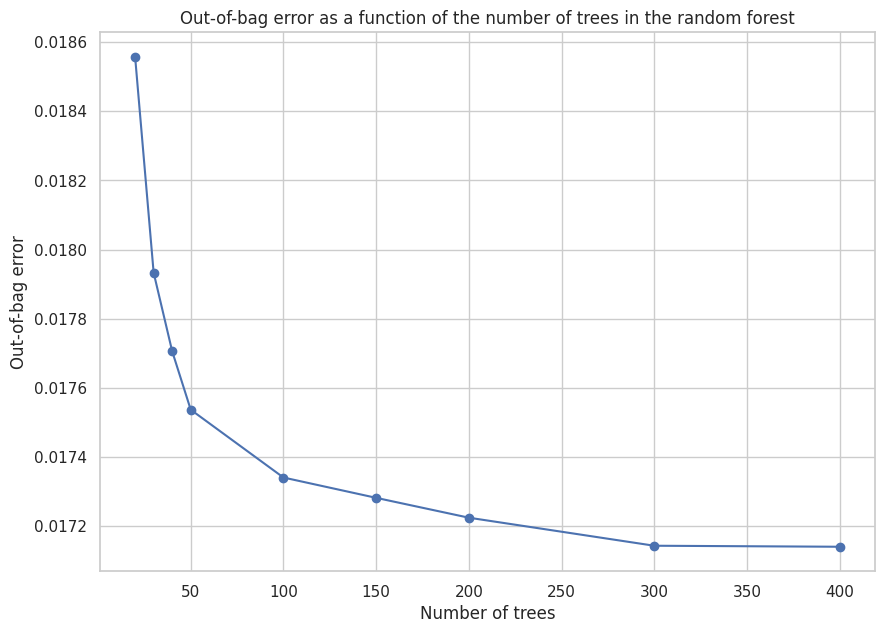

In [45]:
# Plot the oob error as a function of the number of trees
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(rf_oob_df.index, rf_oob_df['oob'], marker='o')
ax.set_xlabel("Number of trees")
ax.set_ylabel("Out-of-bag error")
ax.set_title("Out-of-bag error as a function of the number of trees in the random forest")

As the error seems to stabilize for n_trees > 250, we choose this value for the number of trees in the random forest.

In [46]:
# Initiate the Random Forest Regressor with the chosen number of trees
random_forest_pipeline["regressor"].set_params(oob_score=True, 
                            n_estimators=250,
                            random_state=42, 
                            max_depth=max_depth_cv,
                            max_features=max_features_cv,
                            n_jobs=-1)

# Fit the model
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num_and_bool', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [47]:
# Get the predictions for the train and test sets
y_train_pred_rf = random_forest_pipeline.predict(X_train)
y_test_pred_rf = random_forest_pipeline.predict(X_test)

# Compute the regression metrics for the train and test sets
train_test_rf_error = pd.concat([regression_metrics(y_train, y_train_pred_rf, 'train'),
                                 regression_metrics(y_test, y_test_pred_rf, 'test')],
                                axis=1)

print("Train and test regression metrics for the random forest:")
display(train_test_rf_error)

Train and test regression metrics for the random forest:


,train,test
mse,1.392835e+06,3.785834e+06
r2,9.940279e-01,9.840085e-01


The Random Forest Regressor with 250 trees has an MSE of 3.78e6 and a R² score of 0.984 on the test set, a slight improvement from the 5.18e6 and 0.97 of the Decision Tree Regressor with hyperparameter tuning.